**Mount Google Drive**

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Locate IAA.zip

In [ ]:
import os

ZIP_PATH = "/content/drive/MyDrive/IAA Report.zip"

print("Exists:", os.path.exists(ZIP_PATH))
print("Path:", ZIP_PATH)

Exists: True
Path: /content/drive/MyDrive/IAA Report.zip


**Extract the ZIP**

In [ ]:
import zipfile
import os

EXTRACT_DIR = "/content/IAA_DATA"

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extraction completed.")

Extraction completed.


**Check folder structure**

In [ ]:
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    indent = '    ' * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}    {file}")

    if len(files) > 10:
        print(f"{indent}    ... {len(files)-10} more files")

IAA_DATA/
    IAA Report/
        IAA/
            Dr. Afrina/
                nir47.txt
                0000100.txt
                ibn10.txt
                000040.txt
                ibn82.txt
                000072.txt
                ibn03.txt
                ibn68.txt
                ibn04.txt
                ibn125.txt
                ... 400 more files
            images/
                00001006.jpg
                000051.jpg
                nir33.jpg
                ibn52.jpg
                ibn14.jpg
                ibn117.jpg
                h04.jpg
                00001081.jpg
                000034.jpg
                00001072.jpg
                ... 409 more files
            Dr. Jinia/
                nir47.txt
                0000100.txt
                ibn10.txt
                000040.txt
                ibn82.txt
                000072.txt
                ibn03.txt
                ibn68.txt
                ibn04.txt
                ibn125.txt
                ... 400 

**Automatically find the IAA folder**

In [ ]:
import os

IAA_ROOT = None

for root, dirs, files in os.walk(EXTRACT_DIR):
    folder_names = set(dirs)

    if {"images", "Dr. Jinia", "Dr. Afrina"}.issubset(folder_names):
        IAA_ROOT = root
        break

if IAA_ROOT is None:
    raise FileNotFoundError(
        "Could not find a folder containing images, Dr. Jinia and Dr. Afrina."
    )

IMAGE_DIR = os.path.join(IAA_ROOT, "images")
JINIA_DIR = os.path.join(IAA_ROOT, "Dr. Jinia")
AFRINA_DIR = os.path.join(IAA_ROOT, "Dr. Afrina")

print("IAA ROOT :", IAA_ROOT)
print("Images   :", IMAGE_DIR)
print("Dr. Jinia:", JINIA_DIR)
print("Dr. Afrina:", AFRINA_DIR)

IAA ROOT : /content/IAA_DATA/IAA Report/IAA
Images   : /content/IAA_DATA/IAA Report/IAA/images
Dr. Jinia: /content/IAA_DATA/IAA Report/IAA/Dr. Jinia
Dr. Afrina: /content/IAA_DATA/IAA Report/IAA/Dr. Afrina


**Install required packages**

In [ ]:
!pip -q install scipy pandas openpyxl pillow tqdm matplotlib seaborn

**Define your classes**

In [ ]:
CLASS_NAMES = {
    0: "Missing Teeth",
    1: "Dental Crown",
    2: "Root Canal",
    3: "Caries",
    4: "Broken Down Teeth",
    5: "Wisdom Teeth",
    6: "Healthy Teeth"
}

# All seven classes are bounding-box classes.
# Healthy Teeth uses a full-mouth/dentition bounding box.
OBJECT_CLASSES = list(CLASS_NAMES.keys())

print(CLASS_NAMES)
print("IAA object classes:", OBJECT_CLASSES)


{0: 'Missing Teeth', 1: 'Dental Crown', 2: 'Root Canal', 3: 'Caries', 4: 'Broken Down Teeth', 5: 'Wisdom Teeth', 6: 'Healthy Teeth'}
IAA object classes: [0, 1, 2, 3, 4, 5, 6]


**Count images and annotations**

In [ ]:
from pathlib import Path

def get_files(folder, extensions):
    extensions = {e.lower() for e in extensions}
    return [
        p for p in Path(folder).iterdir()
        if p.is_file() and p.suffix.lower() in extensions
    ]
from pathlib import Path

def get_files(folder, extensions):
    extensions = {e.lower() for e in extensions}
    return [
        p for p in Path(folder).iterdir()
        if p.is_file() and p.suffix.lower() in extensions
    ]

image_files = get_files(IMAGE_DIR, {".jpg", ".jpeg", ".png", ".bmp", ".webp"})
jinia_files = get_files(JINIA_DIR, {".txt"})
afrina_files = get_files(AFRINA_DIR, {".txt"})

print("Images:", len(image_files))
print("Dr. Jinia labels:", len(jinia_files))
print("Dr. Afrina labels:", len(afrina_files))
image_files = get_files(IMAGE_DIR, {".jpg", ".jpeg", ".png", ".bmp", ".webp"})
jinia_files = get_files(JINIA_DIR, {".txt"})
afrina_files = get_files(AFRINA_DIR, {".txt"})

print("Images:", len(image_files))
print("Dr. Jinia labels:", len(jinia_files))
print("Dr. Afrina labels:", len(afrina_files))

Images: 419
Dr. Jinia labels: 410
Dr. Afrina labels: 410
Images: 419
Dr. Jinia labels: 410
Dr. Afrina labels: 410


**Verify that the same images are being compared**

In [ ]:
image_stems = {p.stem for p in image_files}
jinia_stems = {p.stem for p in jinia_files}
afrina_stems = {p.stem for p in afrina_files}

print("Images:", len(image_stems))
print("Jinia:", len(jinia_stems))
print("Afrina:", len(afrina_stems))

print("\nImages missing from Jinia:")
print(sorted(image_stems - jinia_stems)[:20])

print("\nImages missing from Afrina:")
print(sorted(image_stems - afrina_stems)[:20])

print("\nJinia/Afrina mismatch:")
print(sorted(jinia_stems.symmetric_difference(afrina_stems))[:20])

Images: 419
Jinia: 410
Afrina: 410

Images missing from Jinia:
['000091', '000092', '000093', '000094', '000095', '000096', '000097', '000098', '000099']

Images missing from Afrina:
['000091', '000092', '000093', '000094', '000095', '000096', '000097', '000098', '000099']

Jinia/Afrina mismatch:
[]


**Load YOLO annotations**

In [ ]:
import numpy as np

def load_yolo_annotation(txt_path):
    """
    Returns:
        list of dictionaries:
        {
            'class_id': int,
            'x': float,
            'y': float,
            'w': float,
            'h': float
        }
    """

    annotations = []

    if not os.path.exists(txt_path):
        return annotations

    with open(txt_path, "r") as f:
        lines = f.readlines()

    for line_number, line in enumerate(lines, start=1):
        line = line.strip()

        if not line:
            continue

        parts = line.split()

        if len(parts) != 5:
            raise ValueError(
                f"Malformed annotation: {txt_path}, "
                f"line {line_number}: {line}"
            )

        class_id = int(float(parts[0]))
        x = float(parts[1])
        y = float(parts[2])
        w = float(parts[3])
        h = float(parts[4])

        annotations.append({
            "class_id": class_id,
            "x": x,
            "y": y,
            "w": w,
            "h": h
        })

    return annotations

**Convert YOLO boxes to XYXY**

In [ ]:
def yolo_to_xyxy(annotation):
    x = annotation["x"]
    y = annotation["y"]
    w = annotation["w"]
    h = annotation["h"]

    x1 = x - w / 2
    y1 = y - h / 2
    x2 = x + w / 2
    y2 = y + h / 2

    return [x1, y1, x2, y2]

**IoU function**

In [ ]:
def calculate_iou(box1, box2):
    """
    Calculate IoU between two normalized XYXY boxes.
    """

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection_width = max(0.0, x2 - x1)
    intersection_height = max(0.0, y2 - y1)

    intersection_area = (
        intersection_width * intersection_height
    )

    area1 = max(0.0, box1[2] - box1[0]) * \
            max(0.0, box1[3] - box1[1])

    area2 = max(0.0, box2[2] - box2[0]) * \
            max(0.0, box2[3] - box2[1])

    union_area = area1 + area2 - intersection_area

    if union_area <= 0:
        return 0.0

    return intersection_area / union_area

**Import Hungarian matching**

In [ ]:
from scipy.optimize import linear_sum_assignment

**Object matching function**

In [ ]:
IOU_THRESHOLD = 0.50

# IMPORTANT:
# All seven classes are represented by bounding boxes.
# Healthy Teeth is NOT an image-level-only label: both doctors
# draw a full-mouth/dentition bounding box and assign class ID 6.
OBJECT_CLASSES = list(CLASS_NAMES.keys())


def match_annotations(jinia_annotations, afrina_annotations,
                      iou_threshold=IOU_THRESHOLD):

    # Use ALL seven bounding-box classes, including Healthy Teeth.
    jinia_objects = [
        a for a in jinia_annotations
        if a["class_id"] in OBJECT_CLASSES
    ]

    afrina_objects = [
        a for a in afrina_annotations
        if a["class_id"] in OBJECT_CLASSES
    ]

    if len(jinia_objects) == 0 or len(afrina_objects) == 0:
        return {
            "matches": [],
            "jinia_unmatched": list(range(len(jinia_objects))),
            "afrina_unmatched": list(range(len(afrina_objects)))
        }

    iou_matrix = np.zeros(
        (len(jinia_objects), len(afrina_objects))
    )

    for i, jinia in enumerate(jinia_objects):
        box1 = yolo_to_xyxy(jinia)

        for j, afrina in enumerate(afrina_objects):
            box2 = yolo_to_xyxy(afrina)

            iou_matrix[i, j] = calculate_iou(box1, box2)

    # Hungarian algorithm maximizes total IoU.
    row_ind, col_ind = linear_sum_assignment(-iou_matrix)

    matches = []
    matched_jinia = set()
    matched_afrina = set()

    for i, j in zip(row_ind, col_ind):

        iou = iou_matrix[i, j]

        if iou >= iou_threshold:

            matches.append({
                "jinia_index": i,
                "afrina_index": j,
                "iou": float(iou),
                "jinia_class": jinia_objects[i]["class_id"],
                "afrina_class": afrina_objects[j]["class_id"]
            })

            matched_jinia.add(i)
            matched_afrina.add(j)

    jinia_unmatched = [
        i for i in range(len(jinia_objects))
        if i not in matched_jinia
    ]

    afrina_unmatched = [
        j for j in range(len(afrina_objects))
        if j not in matched_afrina
    ]

    return {
        "matches": matches,
        "jinia_unmatched": jinia_unmatched,
        "afrina_unmatched": afrina_unmatched
    }


**Test the matching function**

In [ ]:
sample_image = sorted(image_stems)[0]

jinia_txt = os.path.join(
    JINIA_DIR,
    sample_image + ".txt"
)

afrina_txt = os.path.join(
    AFRINA_DIR,
    sample_image + ".txt"
)

jinia_ann = load_yolo_annotation(jinia_txt)
afrina_ann = load_yolo_annotation(afrina_txt)

result = match_annotations(
    jinia_ann,
    afrina_ann,
    IOU_THRESHOLD
)

print("Image:", sample_image)
print("Jinia boxes:", len(jinia_ann))
print("Afrina boxes:", len(afrina_ann))
print("Matched:", len(result["matches"]))
print("Jinia unmatched:", len(result["jinia_unmatched"]))
print("Afrina unmatched:", len(result["afrina_unmatched"]))

for m in result["matches"][:10]:
    print(m)

Image: 00001
Jinia boxes: 4
Afrina boxes: 4
Matched: 4
Jinia unmatched: 0
Afrina unmatched: 0
{'jinia_index': np.int64(0), 'afrina_index': np.int64(0), 'iou': 0.9474478614771702, 'jinia_class': 5, 'afrina_class': 5}
{'jinia_index': np.int64(1), 'afrina_index': np.int64(1), 'iou': 0.9580654197993141, 'jinia_class': 5, 'afrina_class': 5}
{'jinia_index': np.int64(2), 'afrina_index': np.int64(2), 'iou': 0.970456268984953, 'jinia_class': 5, 'afrina_class': 5}
{'jinia_index': np.int64(3), 'afrina_index': np.int64(3), 'iou': 0.9642437328555605, 'jinia_class': 5, 'afrina_class': 5}


**Run IAA across all 419 images**

In [ ]:
from tqdm.auto import tqdm
import pandas as pd

all_results = []
all_matches = []

for stem in tqdm(sorted(image_stems)):

    jinia_txt = os.path.join(
        JINIA_DIR,
        stem + ".txt"
    )

    afrina_txt = os.path.join(
        AFRINA_DIR,
        stem + ".txt"
    )

    jinia_ann = load_yolo_annotation(jinia_txt)
    afrina_ann = load_yolo_annotation(afrina_txt)

    result = match_annotations(
        jinia_ann,
        afrina_ann,
        IOU_THRESHOLD
    )


    # Image summary — all seven classes, including Healthy Teeth, are bounding boxes
    all_results.append({
        "image": stem,
        "jinia_total_boxes": len(jinia_ann),
        "afrina_total_boxes": len(afrina_ann),
        "matched_boxes": len(result["matches"]),
        "jinia_unmatched": len(result["jinia_unmatched"]),
        "afrina_unmatched": len(result["afrina_unmatched"]),

    })

    # Detailed matched boxes
    for match in result["matches"]:

        all_matches.append({
            "image": stem,
            "jinia_class_id": match["jinia_class"],
            "jinia_class": CLASS_NAMES[
                match["jinia_class"]
            ],
            "afrina_class_id": match["afrina_class"],
            "afrina_class": CLASS_NAMES[
                match["afrina_class"]
            ],
            "iou": match["iou"],
            "class_agreement": int(
                match["jinia_class"] ==
                match["afrina_class"]
            )
        })

results_df = pd.DataFrame(all_results)
matches_df = pd.DataFrame(all_matches)

print("Images analyzed:", len(results_df))
print("Matched objects:", len(matches_df))

  0%|          | 0/419 [00:00<?, ?it/s]

Images analyzed: 419
Matched objects: 1854


**Basic IAA summary**

In [ ]:
total_jinia = results_df["jinia_total_boxes"].sum()
total_afrina = results_df["afrina_total_boxes"].sum()

total_matched = len(matches_df)

total_jinia_unmatched = results_df[
    "jinia_unmatched"
].sum()

total_afrina_unmatched = results_df[
    "afrina_unmatched"
].sum()

print("====================================")
print("IAA SUMMARY")
print("====================================")

print("IAA images:", len(results_df))
print("Dr. Jinia total boxes:", total_jinia)
print("Dr. Afrina total boxes:", total_afrina)
print("Matched boxes:", total_matched)
print("Jinia unmatched:", total_jinia_unmatched)
print("Afrina unmatched:", total_afrina_unmatched)

IAA SUMMARY
IAA images: 419
Dr. Jinia total boxes: 1879
Dr. Afrina total boxes: 1923
Matched boxes: 1854
Jinia unmatched: 25
Afrina unmatched: 69


In [ ]:
stem = "000010"

jinia_txt = os.path.join(JINIA_DIR, stem + ".txt")
afrina_txt = os.path.join(AFRINA_DIR, stem + ".txt")

print("Jinia file:")
print(jinia_txt)
print("Exists:", os.path.exists(jinia_txt))

print("\nAfrina file:")
print(afrina_txt)
print("Exists:", os.path.exists(afrina_txt))

print("\n" + "="*70)
print("DR. JINIA RAW LABEL")
print("="*70)

with open(jinia_txt, "r") as f:
    jinia_raw = f.read()

print(jinia_raw)

print("\n" + "="*70)
print("DR. AFRINA RAW LABEL")
print("="*70)

with open(afrina_txt, "r") as f:
    afrina_raw = f.read()

print(afrina_raw)

Jinia file:
/content/IAA_DATA/IAA Report/IAA/Dr. Jinia/000010.txt
Exists: True

Afrina file:
/content/IAA_DATA/IAA Report/IAA/Dr. Afrina/000010.txt
Exists: True

DR. JINIA RAW LABEL
3 0.359986 0.672207 0.016061 0.049202
3 0.377793 0.681184 0.011872 0.055186


DR. AFRINA RAW LABEL
3 0.359287 0.672430 0.016834 0.047968



**IoU statistics**

In [ ]:
# Full-data IoU statistics — every box counts, matched AND unmatched.
#
# A matched pair's IoU value is credited to BOTH boxes in the pair
# (that's how well each of those two boxes did). An unmatched box
# (missed by the other doctor, or dropped by the threshold) is
# credited an IoU of 0 — it has no accepted counterpart.
#
# This replaces conditioning the stats on matches_df alone, which
# only contains boxes that already cleared the threshold and would
# always show "IoU >= 0.50: 100%" by construction.

total_boxes = total_jinia + total_afrina

if len(matches_df) > 0:
    matched_iou_per_box = pd.concat(
        [matches_df["iou"], matches_df["iou"]], ignore_index=True
    )
else:
    matched_iou_per_box = pd.Series([], dtype=float)

unmatched_iou_per_box = pd.Series(
    [0.0] * (total_jinia_unmatched + total_afrina_unmatched)
)

full_iou_series = pd.concat(
    [matched_iou_per_box, unmatched_iou_per_box], ignore_index=True
)

assert len(full_iou_series) == total_boxes

print("====================================")
print("IoU AGREEMENT — FULL DATA (ALL BOXES)")
print("====================================")

print(f"Total boxes scored : {len(full_iou_series)}")
print(f"Mean IoU   : {full_iou_series.mean():.4f}")
print(f"Median IoU : {full_iou_series.median():.4f}")
print(f"Std IoU    : {full_iou_series.std():.4f}")
print(f"Min IoU    : {full_iou_series.min():.4f}")
print(f"Max IoU    : {full_iou_series.max():.4f}")

boxes_iou_ge_50 = int((full_iou_series >= 0.50).sum())
boxes_iou_lt_50 = int((full_iou_series < 0.50).sum())
pct_iou_ge_50_full = boxes_iou_ge_50 / total_boxes * 100 if total_boxes else 0
pct_iou_lt_50_full = 100 - pct_iou_ge_50_full

boxes_iou_ge_80 = int((full_iou_series >= 0.80).sum())
boxes_iou_lt_80 = int((full_iou_series < 0.80).sum())
pct_iou_ge_80_full = boxes_iou_ge_80 / total_boxes * 100 if total_boxes else 0
pct_iou_lt_80_full = 100 - pct_iou_ge_80_full

print()
print(f"IoU >= 0.50 (% of all boxes): {pct_iou_ge_50_full:.2f}%  ({boxes_iou_ge_50} boxes)")
print(f"IoU <  0.50 (% of all boxes): {pct_iou_lt_50_full:.2f}%  ({boxes_iou_lt_50} boxes)")
print()
print(f"IoU >= 0.80 (% of all boxes): {pct_iou_ge_80_full:.2f}%  ({boxes_iou_ge_80} boxes)")
print(f"IoU <  0.80 (% of all boxes): {pct_iou_lt_80_full:.2f}%  ({boxes_iou_lt_80} boxes)")

assert abs((pct_iou_ge_50_full + pct_iou_lt_50_full) - 100) < 1e-6
assert abs((pct_iou_ge_80_full + pct_iou_lt_80_full) - 100) < 1e-6


IoU AGREEMENT — FULL DATA (ALL BOXES)
Total boxes scored : 3802
Mean IoU   : 0.8941
Median IoU : 0.9224
Std IoU    : 0.1493
Min IoU    : 0.0000
Max IoU    : 0.9985

IoU >= 0.50 (% of all boxes): 97.53%  (3708 boxes)
IoU <  0.50 (% of all boxes): 2.47%  (94 boxes)

IoU >= 0.80 (% of all boxes): 95.63%  (3636 boxes)
IoU <  0.80 (% of all boxes): 4.37%  (166 boxes)


In [ ]:
from collections import defaultdict
import pandas as pd

def fmt_pct(v):
    return f"{v:.2f}%"

def fmt4(v):
    return f"{v:.4f}"

def run_full_iaa_analysis(iou_threshold):
    """
    Re-runs the ENTIRE matching + agreement pipeline at a given
    IoU threshold, over every image and every box (full data —
    matched AND unmatched boxes both count in every stat below).
    """

    results_rows = []
    match_rows = []

    for stem in sorted(image_stems):

        jinia_txt = os.path.join(JINIA_DIR, stem + ".txt")
        afrina_txt = os.path.join(AFRINA_DIR, stem + ".txt")

        jinia_ann = load_yolo_annotation(jinia_txt)
        afrina_ann = load_yolo_annotation(afrina_txt)

        result = match_annotations(jinia_ann, afrina_ann, iou_threshold)

        results_rows.append({
            "image": stem,
            "jinia_total_boxes": len(jinia_ann),
            "afrina_total_boxes": len(afrina_ann),
            "matched_boxes": len(result["matches"]),
            "jinia_unmatched": len(result["jinia_unmatched"]),
            "afrina_unmatched": len(result["afrina_unmatched"]),
        })

        for m in result["matches"]:
            match_rows.append({
                "image": stem,
                "jinia_class_id": m["jinia_class"],
                "afrina_class_id": m["afrina_class"],
                "iou": m["iou"],
                "class_agreement": int(m["jinia_class"] == m["afrina_class"])
            })

    res_df = pd.DataFrame(results_rows)
    mat_df = pd.DataFrame(match_rows)

    total_j = res_df["jinia_total_boxes"].sum()
    total_a = res_df["afrina_total_boxes"].sum()
    total_m = len(mat_df)
    total_ju = res_df["jinia_unmatched"].sum()
    total_au = res_df["afrina_unmatched"].sum()

    total_all_boxes = total_j + total_a
    boxes_ge = total_m * 2                     # each match = 1 box from each doctor
    boxes_lt = total_ju + total_au
    pct_ge = boxes_ge / total_all_boxes * 100 if total_all_boxes else 0
    pct_lt = 100 - pct_ge

    # ---- Full-data IoU distribution: every box gets a score. ----
    # Matched boxes get the pair's IoU (credited to both sides);
    # unmatched boxes get 0 (no accepted counterpart).
    if len(mat_df) > 0:
        matched_iou_per_box = pd.concat(
            [mat_df["iou"], mat_df["iou"]], ignore_index=True
        )
    else:
        matched_iou_per_box = pd.Series([], dtype=float)

    unmatched_iou_per_box = pd.Series([0.0] * (total_ju + total_au))
    full_iou_per_box = pd.concat(
        [matched_iou_per_box, unmatched_iou_per_box], ignore_index=True
    )

    if len(full_iou_per_box) > 0:
        mean_iou = full_iou_per_box.mean()
        median_iou = full_iou_per_box.median()
        std_iou = full_iou_per_box.std()
        min_iou = full_iou_per_box.min()
        max_iou = full_iou_per_box.max()
    else:
        mean_iou = median_iou = std_iou = min_iou = max_iou = float("nan")

    # ---- Full-data class agreement ----
    # A box only counts as "agreeing" if it was spatially matched
    # AND both doctors gave it the same class. Unmatched boxes count
    # as disagreements — there is no counterpart to agree with.
    matched_class_agree_pairs = (
        int(mat_df["class_agreement"].sum()) if len(mat_df) > 0 else 0
    )
    agreement_boxes = matched_class_agree_pairs * 2
    disagreement_boxes = total_all_boxes - agreement_boxes
    class_agree_pct = (
        agreement_boxes / total_all_boxes * 100 if total_all_boxes else 0
    )

    # ---- TP / FP / FN per class, at this threshold, full data ----
    tp_d = defaultdict(int)
    fp_d = defaultdict(int)
    fn_d = defaultdict(int)

    for _, row in mat_df.iterrows():
        jc = int(row["jinia_class_id"])
        ac = int(row["afrina_class_id"])
        if jc == ac:
            tp_d[jc] += 1
        else:
            fn_d[jc] += 1
            fp_d[ac] += 1

    for stem in sorted(image_stems):
        jinia_txt = os.path.join(JINIA_DIR, stem + ".txt")
        afrina_txt = os.path.join(AFRINA_DIR, stem + ".txt")
        jinia_ann = load_yolo_annotation(jinia_txt)
        afrina_ann = load_yolo_annotation(afrina_txt)
        result = match_annotations(jinia_ann, afrina_ann, iou_threshold)

        jinia_objects = [a for a in jinia_ann if a["class_id"] in OBJECT_CLASSES]
        afrina_objects = [a for a in afrina_ann if a["class_id"] in OBJECT_CLASSES]

        for idx in result["jinia_unmatched"]:
            fn_d[jinia_objects[idx]["class_id"]] += 1
        for idx in result["afrina_unmatched"]:
            fp_d[afrina_objects[idx]["class_id"]] += 1

    per_class_rows = []
    for cls in OBJECT_CLASSES:
        TP = tp_d[cls]
        FP = fp_d[cls]
        FN = fn_d[cls]
        prec = TP / (TP + FP) if (TP + FP) > 0 else 0
        rec = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        per_class_rows.append({
            "Class ID": cls, "Class": CLASS_NAMES[cls],
            "TP": TP, "FP": FP, "FN": FN,
            "Precision": prec, "Recall": rec, "F1": f1
        })
    per_class_df = pd.DataFrame(per_class_rows)

    macro_p = per_class_df["Precision"].mean()
    macro_r = per_class_df["Recall"].mean()
    macro_f1v = per_class_df["F1"].mean()

    return {
        "iou_threshold": iou_threshold,
        "results_df": res_df,
        "matches_df": mat_df,
        "per_class_df": per_class_df,
        "total_jinia": int(total_j),
        "total_afrina": int(total_a),
        "total_boxes": int(total_all_boxes),
        "total_matched": int(total_m),
        "total_jinia_unmatched": int(total_ju),
        "total_afrina_unmatched": int(total_au),
        "boxes_ge_threshold": int(boxes_ge),
        "boxes_lt_threshold": int(boxes_lt),
        "pct_ge_threshold_full": pct_ge,
        "pct_lt_threshold_full": pct_lt,
        "mean_iou": mean_iou,
        "median_iou": median_iou,
        "std_iou": std_iou,
        "min_iou": min_iou,
        "max_iou": max_iou,
        "class_agreement_count": agreement_boxes,
        "class_agreement_pct": class_agree_pct,
        "class_disagreement_count": disagreement_boxes,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1v,
    }

iaa_050 = run_full_iaa_analysis(0.50)
iaa_080 = run_full_iaa_analysis(0.80)

print("Done: full pipeline re-run at IoU 0.50 and IoU 0.80, on all boxes (full data throughout).")

Done: full pipeline re-run at IoU 0.50 and IoU 0.80, on all boxes (full data throughout).


In [ ]:
iou_thresholds = [0.50, 0.60, 0.70, 0.80, 0.90]

all_iaa_results = {}
for threshold in iou_thresholds:
    all_iaa_results[f"iaa_{threshold:.2f}"] = run_full_iaa_analysis(threshold)


comparison_rows = []
metrics = [
    ("IoU threshold used for matching", lambda res: res["iou_threshold"]),
    ("Dr. Jinia total boxes", lambda res: res["total_jinia"]),
    ("Dr. Afrina total boxes", lambda res: res["total_afrina"]),
    ("Total boxes (Jinia + Afrina) — full data", lambda res: res["total_boxes"]),
    ("Matched object pairs", lambda res: res["total_matched"]),
    ("Jinia unmatched boxes", lambda res: res["total_jinia_unmatched"]),
    ("Afrina unmatched boxes", lambda res: res["total_afrina_unmatched"]),
    ("Boxes with IoU >= threshold (count, full data)", lambda res: res["boxes_ge_threshold"]),
    ("Boxes with IoU < threshold (count, full data)", lambda res: res["boxes_lt_threshold"]),
    ("IoU >= threshold (% of ALL boxes, full data)", lambda res: fmt_pct(res["pct_ge_threshold_full"])),
    ("IoU <  threshold (% of ALL boxes, full data)", lambda res: fmt_pct(res["pct_lt_threshold_full"])),
    ("Mean IoU (full data, all boxes)", lambda res: fmt4(res["mean_iou"])),
    ("Median IoU (full data, all boxes)", lambda res: fmt4(res["median_iou"])),
    ("Std IoU (full data, all boxes)", lambda res: fmt4(res["std_iou"])),
    ("Min IoU (full data, all boxes)", lambda res: fmt4(res["min_iou"])),
    ("Max IoU (full data, all boxes)", lambda res: fmt4(res["max_iou"])),
    ("Class agreement (%, full data — all boxes)", lambda res: fmt_pct(res["class_agreement_pct"])),
    ("Class disagreements (count, full data — all boxes)", lambda res: res["class_disagreement_count"]),
    ("Macro Precision (7 classes)", lambda res: fmt4(res["macro_precision"])),
    ("Macro Recall (7 classes)", lambda res: fmt4(res["macro_recall"])),
    ("Macro F1 (7 classes)", lambda res: fmt4(res["macro_f1"]))
]

for metric_name, metric_func in metrics:
    row = [metric_name]
    for threshold in iou_thresholds:
        row.append(metric_func(all_iaa_results[f"iaa_{threshold:.2f}"]))
    comparison_rows.append(row)

columns = ["Metric"] + [f"IoU >= {t:.2f}" for t in iou_thresholds]
threshold_comparison_df = pd.DataFrame(
    comparison_rows,
    columns=columns
)

print("======================================================================")
print("IoU THRESHOLD COMPARISON — FULL DATA (all boxes)")
print("======================================================================")
print(threshold_comparison_df.to_string(index=False))
print("======================================================================")

IoU THRESHOLD COMPARISON — FULL DATA (all boxes)
                                            Metric IoU >= 0.50 IoU >= 0.60 IoU >= 0.70 IoU >= 0.80 IoU >= 0.90
                   IoU threshold used for matching         0.5         0.6         0.7         0.8         0.9
                             Dr. Jinia total boxes        1879        1879        1879        1879        1879
                            Dr. Afrina total boxes        1923        1923        1923        1923        1923
          Total boxes (Jinia + Afrina) — full data        3802        3802        3802        3802        3802
                              Matched object pairs        1854        1854        1853        1818        1285
                             Jinia unmatched boxes          25          25          26          61         594
                            Afrina unmatched boxes          69          69          70         105         638
    Boxes with IoU >= threshold (count, full data)        3708 

In [ ]:
def fmt_pct(v):
    return f"{v:.2f}%"

def fmt4(v):
    return f"{v:.4f}"

comparison_rows = [
    ("IoU threshold used for matching",
        iaa_050["iou_threshold"], iaa_080["iou_threshold"]),

    ("Dr. Jinia total boxes",
        iaa_050["total_jinia"], iaa_080["total_jinia"]),

    ("Dr. Afrina total boxes",
        iaa_050["total_afrina"], iaa_080["total_afrina"]),

    ("Total boxes (Jinia + Afrina) — full data",
        iaa_050["total_boxes"], iaa_080["total_boxes"]),

    ("Matched object pairs",
        iaa_050["total_matched"], iaa_080["total_matched"]),

    ("Jinia unmatched boxes",
        iaa_050["total_jinia_unmatched"], iaa_080["total_jinia_unmatched"]),

    ("Afrina unmatched boxes",
        iaa_050["total_afrina_unmatched"], iaa_080["total_afrina_unmatched"]),

    ("Boxes with IoU >= threshold (count, full data)",
        iaa_050["boxes_ge_threshold"], iaa_080["boxes_ge_threshold"]),

    ("Boxes with IoU < threshold (count, full data)",
        iaa_050["boxes_lt_threshold"], iaa_080["boxes_lt_threshold"]),

    ("IoU >= threshold (% of ALL boxes, full data)",
        fmt_pct(iaa_050["pct_ge_threshold_full"]), fmt_pct(iaa_080["pct_ge_threshold_full"])),

    ("IoU <  threshold (% of ALL boxes, full data)",
        fmt_pct(iaa_050["pct_lt_threshold_full"]), fmt_pct(iaa_080["pct_lt_threshold_full"])),

    ("Mean IoU (full data, all boxes)",
        fmt4(iaa_050["mean_iou"]), fmt4(iaa_080["mean_iou"])),

    ("Median IoU (full data, all boxes)",
        fmt4(iaa_050["median_iou"]), fmt4(iaa_080["median_iou"])),

    ("Std IoU (full data, all boxes)",
        fmt4(iaa_050["std_iou"]), fmt4(iaa_080["std_iou"])),

    ("Min IoU (full data, all boxes)",
        fmt4(iaa_050["min_iou"]), fmt4(iaa_080["min_iou"])),

    ("Max IoU (full data, all boxes)",
        fmt4(iaa_050["max_iou"]), fmt4(iaa_080["max_iou"])),

    ("Class agreement (%, full data — all boxes)",
        fmt_pct(iaa_050["class_agreement_pct"]), fmt_pct(iaa_080["class_agreement_pct"])),

    ("Class disagreements (count, full data — all boxes)",
        iaa_050["class_disagreement_count"], iaa_080["class_disagreement_count"]),

    ("Macro Precision (7 classes)",
        fmt4(iaa_050["macro_precision"]), fmt4(iaa_080["macro_precision"])),

    ("Macro Recall (7 classes)",
        fmt4(iaa_050["macro_recall"]), fmt4(iaa_080["macro_recall"])),

    ("Macro F1 (7 classes)",
        fmt4(iaa_050["macro_f1"]), fmt4(iaa_080["macro_f1"])),
]

threshold_comparison_df = pd.DataFrame(
    comparison_rows,
    columns=["Metric", "IoU >= 0.50", "IoU >= 0.80"]
)

threshold_comparison_df


,Metric,IoU >= 0.50,IoU >= 0.80
0,IoU threshold used for matching,0.5,0.8
1,Dr. Jinia total boxes,1879,1879
2,Dr. Afrina total boxes,1923,1923
3,Total boxes (Jinia + Afrina) — full data,3802,3802
4,Matched object pairs,1854,1818
5,Jinia unmatched boxes,25,61
6,Afrina unmatched boxes,69,105
7,"Boxes with IoU >= threshold (count, full data)",3708,3636
8,"Boxes with IoU < threshold (count, full data)",94,166
9,"IoU >= threshold (% of ALL boxes, full data)",97.53%,95.63%


In [ ]:
# Per-class Precision / Recall / F1, side by side at both thresholds

per_class_050 = iaa_050["per_class_df"][
    ["Class ID", "Class", "TP", "FP", "FN", "Precision", "Recall", "F1"]
].copy()
per_class_050.columns = [
    "Class ID", "Class",
    "TP_@0.50", "FP_@0.50", "FN_@0.50",
    "Precision_@0.50", "Recall_@0.50", "F1_@0.50"
]

per_class_080 = iaa_080["per_class_df"][
    ["TP", "FP", "FN", "Precision", "Recall", "F1"]
].copy()
per_class_080.columns = [
    "TP_@0.80", "FP_@0.80", "FN_@0.80",
    "Precision_@0.80", "Recall_@0.80", "F1_@0.80"
]

per_class_threshold_comparison_df = pd.concat(
    [per_class_050, per_class_080], axis=1
)

per_class_threshold_comparison_df


,Class ID,Class,TP_@0.50,FP_@0.50,FN_@0.50,Precision_@0.50,Recall_@0.50,F1_@0.50,TP_@0.80,FP_@0.80,FN_@0.80,Precision_@0.80,Recall_@0.80,F1_@0.80
0,0,Missing Teeth,507,6,13,0.988304,0.975000,0.981607,498,15,22,0.970760,0.957692,0.964182
1,1,Dental Crown,353,40,0,0.898219,1.000000,0.946381,351,42,2,0.893130,0.994334,0.941019
2,2,Root Canal,401,5,12,0.987685,0.970944,0.979243,382,24,31,0.940887,0.924939,0.932845
3,3,Caries,229,3,4,0.987069,0.982833,0.984946,224,8,9,0.965517,0.961373,0.963441
4,4,Broken Down Teeth,145,2,2,0.986395,0.986395,0.986395,144,3,3,0.979592,0.979592,0.979592
5,5,Wisdom Teeth,157,22,4,0.877095,0.975155,0.923529,157,22,4,0.877095,0.975155,0.923529
6,6,Healthy Teeth,52,1,0,0.981132,1.000000,0.990476,52,1,0,0.981132,1.000000,0.990476


**Class agreement**

In [ ]:
# Full-data class agreement — every box counts, matched AND unmatched.
# A box only counts as "agreeing" if it was spatially matched to a
# counterpart AND both doctors assigned it the same class. A box with
# no accepted spatial match (unmatched) counts as a disagreement,
# since there is no counterpart to compare classes against.

matched_class_agree_pairs = (
    int(matches_df["class_agreement"].sum()) if len(matches_df) > 0 else 0
)
matched_class_disagree_pairs = total_matched - matched_class_agree_pairs

class_agreement_count = matched_class_agree_pairs * 2          # both boxes in an agreeing pair
class_disagreement_count = (
    matched_class_disagree_pairs * 2                            # both boxes in a matched-but-different-class pair
    + total_jinia_unmatched + total_afrina_unmatched             # boxes with no spatial match at all
)

class_agreement_percentage = (
    class_agreement_count / total_boxes * 100
    if total_boxes > 0 else 0
)

print("====================================")
print("CLASS AGREEMENT — FULL DATA (ALL BOXES)")
print("====================================")

print("Total boxes scored:", total_boxes)
print("Boxes in agreement (matched + same class):", class_agreement_count)
print("Boxes in disagreement (different class OR unmatched):", class_disagreement_count)
print(f"Class agreement: {class_agreement_percentage:.2f}%")


CLASS AGREEMENT — FULL DATA (ALL BOXES)
Total boxes scored: 3802
Boxes in agreement (matched + same class): 3688
Boxes in disagreement (different class OR unmatched): 114
Class agreement: 97.00%


**Create class confusion matrix**

In [ ]:
from sklearn.metrics import confusion_matrix

# Full-data confusion matrix: unmatched boxes are folded in as an
# explicit "No Match" category, so every box (matched and unmatched)
# is represented -- not just the boxes that already found a partner.

NO_MATCH = "No Match"
CM_LABELS = OBJECT_CLASSES + [NO_MATCH]
CM_LABEL_NAMES = [CLASS_NAMES[i] for i in OBJECT_CLASSES] + [NO_MATCH]

matched_for_cm = matches_df[
    (matches_df["jinia_class_id"].isin(OBJECT_CLASSES)) &
    (matches_df["afrina_class_id"].isin(OBJECT_CLASSES))
]

y_true_full = matched_for_cm["jinia_class_id"].tolist()
y_pred_full = matched_for_cm["afrina_class_id"].tolist()

for stem in sorted(image_stems):

    jinia_txt = os.path.join(JINIA_DIR, stem + ".txt")
    afrina_txt = os.path.join(AFRINA_DIR, stem + ".txt")

    jinia_ann = load_yolo_annotation(jinia_txt)
    afrina_ann = load_yolo_annotation(afrina_txt)

    result = match_annotations(jinia_ann, afrina_ann, IOU_THRESHOLD)

    jinia_objects = [a for a in jinia_ann if a["class_id"] in OBJECT_CLASSES]
    afrina_objects = [a for a in afrina_ann if a["class_id"] in OBJECT_CLASSES]

    # Jinia drew a box Afrina has no accepted match for.
    for idx in result["jinia_unmatched"]:
        y_true_full.append(jinia_objects[idx]["class_id"])
        y_pred_full.append(NO_MATCH)

    # Afrina drew a box Jinia has no accepted match for.
    for idx in result["afrina_unmatched"]:
        y_true_full.append(NO_MATCH)
        y_pred_full.append(afrina_objects[idx]["class_id"])

cm = confusion_matrix(
    y_true_full,
    y_pred_full,
    labels=CM_LABELS
)

cm_df = pd.DataFrame(
    cm,
    index=CM_LABEL_NAMES,
    columns=CM_LABEL_NAMES
)

cm_df


,Missing Teeth,Dental Crown,Root Canal,Caries,Broken Down Teeth,Wisdom Teeth,Healthy Teeth,No Match
Missing Teeth,507,5,0,0,1,0,0,7
Dental Crown,0,353,0,0,0,0,0,0
Root Canal,0,1,401,2,0,0,0,9
Caries,0,0,0,229,0,0,0,4
Broken Down Teeth,0,1,0,0,145,0,0,1
Wisdom Teeth,0,0,0,0,0,157,0,4
Healthy Teeth,0,0,0,0,0,0,52,0
No Match,6,33,5,1,1,22,1,0


**Plot the class agreement matrix**

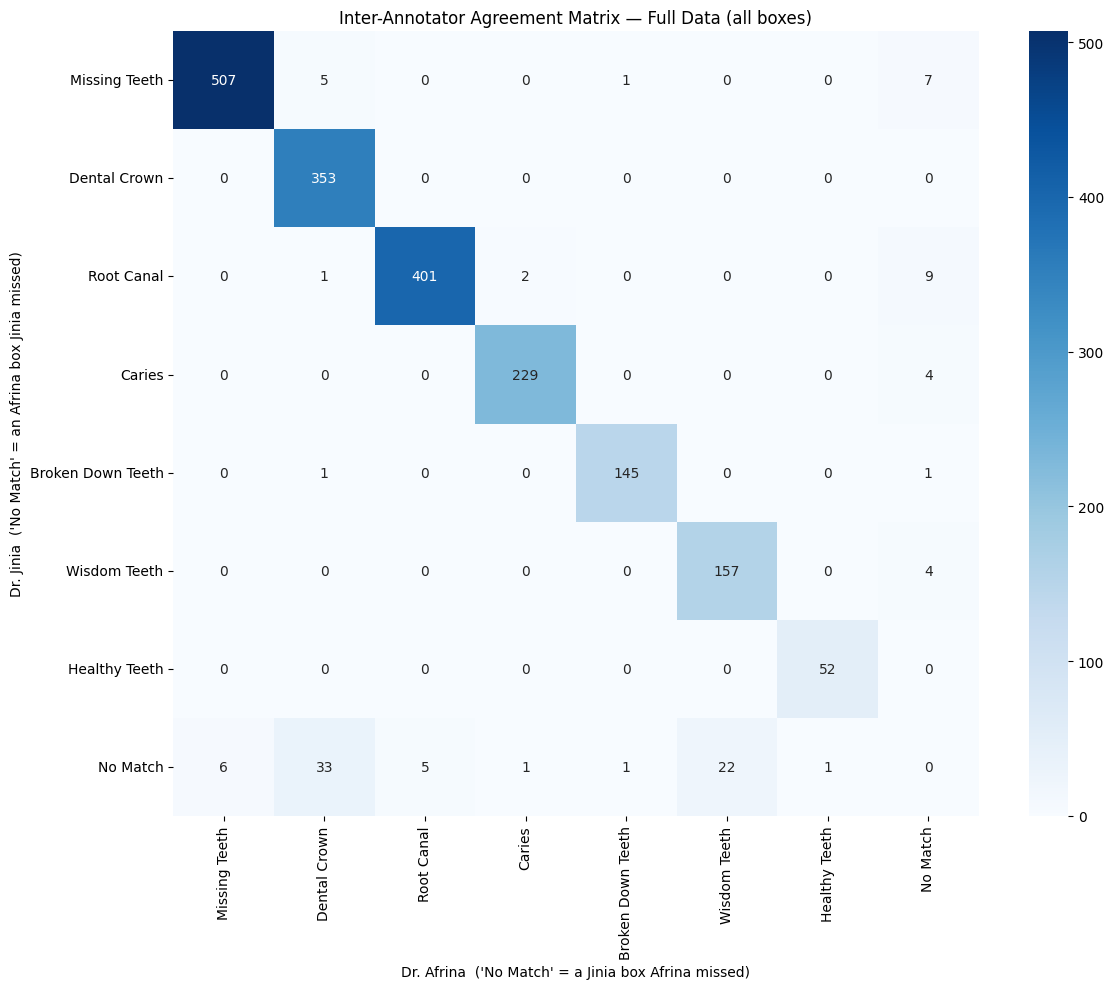

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Dr. Afrina  (\'No Match\' = a Jinia box Afrina missed)")
plt.ylabel("Dr. Jinia  (\'No Match\' = an Afrina box Jinia missed)")
plt.title(
    "Inter-Annotator Agreement Matrix — Full Data (all boxes)"
)

plt.tight_layout()

plt.savefig(
    "/content/IAA_class_agreement_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


**Calculate per-class Precision, Recall and F1**

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

y_true = matched_for_cm["jinia_class_id"]
y_pred = matched_for_cm["afrina_class_id"]

precision, recall, f1, support = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=OBJECT_CLASSES,
        zero_division=0
    )
)

class_metrics = pd.DataFrame({
    "Class ID": OBJECT_CLASSES,
    "Class": [
        CLASS_NAMES[i]
        for i in OBJECT_CLASSES
    ],
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "Matched Support": support
})

class_metrics

,Class ID,Class,Precision,Recall,F1,Matched Support
0,0,Missing Teeth,1.000000,0.988304,0.994118,513
1,1,Dental Crown,0.980556,1.000000,0.990182,353
2,2,Root Canal,1.000000,0.992574,0.996273,404
3,3,Caries,0.991342,1.000000,0.995652,229
4,4,Broken Down Teeth,0.993151,0.993151,0.993151,146
5,5,Wisdom Teeth,1.000000,1.000000,1.000000,157
6,6,Healthy Teeth,1.000000,1.000000,1.000000,52


**Proper object-level TP/FP/FN and F1**

In [ ]:
from collections import defaultdict

tp = defaultdict(int)
fp = defaultdict(int)
fn = defaultdict(int)

# Matched pairs
for _, row in matches_df.iterrows():

    jinia_class = int(row["jinia_class_id"])
    afrina_class = int(row["afrina_class_id"])

    if jinia_class == afrina_class:

        tp[jinia_class] += 1

    else:

        # Jinia says class A, Afrina says class B
        fn[jinia_class] += 1
        fp[afrina_class] += 1


# Unmatched Jinia boxes = FN
# We need to reconstruct them image by image

for stem in sorted(image_stems):

    jinia_txt = os.path.join(
        JINIA_DIR,
        stem + ".txt"
    )

    afrina_txt = os.path.join(
        AFRINA_DIR,
        stem + ".txt"
    )

    jinia_ann = load_yolo_annotation(jinia_txt)
    afrina_ann = load_yolo_annotation(afrina_txt)

    result = match_annotations(
        jinia_ann,
        afrina_ann,
        IOU_THRESHOLD
    )

    jinia_objects = [
        a for a in jinia_ann
        if a["class_id"] in OBJECT_CLASSES
    ]

    afrina_objects = [
        a for a in afrina_ann
        if a["class_id"] in OBJECT_CLASSES
    ]

    # Jinia unmatched = FN
    for idx in result["jinia_unmatched"]:
        cls = jinia_objects[idx]["class_id"]
        fn[cls] += 1

    # Afrina unmatched = FP
    for idx in result["afrina_unmatched"]:
        cls = afrina_objects[idx]["class_id"]
        fp[cls] += 1


metrics_rows = []

for cls in OBJECT_CLASSES:

    TP = tp[cls]
    FP = fp[cls]
    FN = fn[cls]

    precision_value = (
        TP / (TP + FP)
        if (TP + FP) > 0
        else 0
    )

    recall_value = (
        TP / (TP + FN)
        if (TP + FN) > 0
        else 0
    )

    f1_value = (
        2 * precision_value * recall_value /
        (precision_value + recall_value)
        if (precision_value + recall_value) > 0
        else 0
    )

    metrics_rows.append({
        "Class ID": cls,
        "Class": CLASS_NAMES[cls],
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "Precision": precision_value,
        "Recall": recall_value,
        "F1": f1_value
    })

object_metrics_df = pd.DataFrame(metrics_rows)

object_metrics_df

,Class ID,Class,TP,FP,FN,Precision,Recall,F1
0,0,Missing Teeth,507,6,13,0.988304,0.975000,0.981607
1,1,Dental Crown,353,40,0,0.898219,1.000000,0.946381
2,2,Root Canal,401,5,12,0.987685,0.970944,0.979243
3,3,Caries,229,3,4,0.987069,0.982833,0.984946
4,4,Broken Down Teeth,145,2,2,0.986395,0.986395,0.986395
5,5,Wisdom Teeth,157,22,4,0.877095,0.975155,0.923529
6,6,Healthy Teeth,52,1,0,0.981132,1.000000,0.990476


**Macro F1**

In [ ]:
macro_precision = object_metrics_df["Precision"].mean()
macro_recall = object_metrics_df["Recall"].mean()
macro_f1 = object_metrics_df["F1"].mean()

print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall   : {macro_recall:.4f}")
print(f"Macro F1       : {macro_f1:.4f}")

Macro Precision: 0.9580
Macro Recall   : 0.9843
Macro F1       : 0.9704


**Identify disagreement images**

In [ ]:
class_disagreements_df = matches_df[
    matches_df["class_agreement"] == 0
].copy()

In [ ]:
# Identify images requiring clinical review.
# An image requires review if it contains:
#   1) unmatched boxes, OR
#   2) a matched pair with different class labels.

class_disagreement_images = set(
    class_disagreements_df["image"].unique()
) if len(class_disagreements_df) > 0 else set()

disagreement_images = results_df[
    (
        results_df["jinia_unmatched"] > 0
    )
    |
    (
        results_df["afrina_unmatched"] > 0
    )
    |
    (
        results_df["image"].isin(class_disagreement_images)
    )
].copy()

print(
    "Images requiring clinical review:",
    len(disagreement_images)
)

disagreement_images.head(20)


Images requiring clinical review: 57


,image,jinia_total_boxes,afrina_total_boxes,matched_boxes,jinia_unmatched,afrina_unmatched
1,000010,2,1,1,1,0
2,0000100,15,14,14,1,0
4,00001002,1,1,0,1,1
5,00001003,5,4,3,2,1
8,00001006,9,9,9,0,0
15,00001013,3,2,2,1,0
23,00001021,3,2,2,1,0
25,00001023,6,6,6,0,0
27,00001025,9,8,8,1,0
42,00001040,5,5,4,1,1


**Find class disagreements**

In [ ]:
class_disagreements_df = matches_df[
    matches_df["class_agreement"] == 0
].copy()

print(
    "Class disagreement cases:",
    len(class_disagreements_df)
)

class_disagreements_df[
    [
        "image",
        "jinia_class",
        "afrina_class",
        "iou"
    ]
].head(50)

Class disagreement cases: 10


,image,jinia_class,afrina_class,iou
16,0000100,Missing Teeth,Dental Crown,0.926710
49,00001006,Missing Teeth,Dental Crown,0.949448
123,00001023,Root Canal,Caries,0.917933
403,00001070,Missing Teeth,Dental Crown,0.887394
631,000026,Missing Teeth,Dental Crown,0.927263
672,000034,Broken Down Teeth,Dental Crown,0.963520
853,000066,Missing Teeth,Broken Down Teeth,0.901639
961,000085,Root Canal,Caries,0.860764
1397,ibn43,Root Canal,Dental Crown,0.926706
1556,ibn85,Missing Teeth,Dental Crown,0.922215


**Create a detailed disagreement report**

In [ ]:
disagreement_rows = []

for stem in sorted(image_stems):

    jinia_txt = os.path.join(
        JINIA_DIR,
        stem + ".txt"
    )

    afrina_txt = os.path.join(
        AFRINA_DIR,
        stem + ".txt"
    )

    jinia_ann = load_yolo_annotation(jinia_txt)
    afrina_ann = load_yolo_annotation(afrina_txt)

    result = match_annotations(
        jinia_ann,
        afrina_ann,
        IOU_THRESHOLD
    )

    jinia_objects = [
        a for a in jinia_ann
        if a["class_id"] in OBJECT_CLASSES
    ]

    afrina_objects = [
        a for a in afrina_ann
        if a["class_id"] in OBJECT_CLASSES
    ]

    # Class disagreements among spatially matched bounding boxes.
    for m in result["matches"]:

        if m["jinia_class"] != m["afrina_class"]:

            disagreement_rows.append({
                "image": stem,
                "issue": "Class disagreement",
                "Dr_Jinia_class":
                    CLASS_NAMES[m["jinia_class"]],
                "Dr_Afrina_class":
                    CLASS_NAMES[m["afrina_class"]],
                "IoU": m["iou"]
            })

    # Jinia-only boxes = not matched by Afrina.
    for idx in result["jinia_unmatched"]:

        cls = jinia_objects[idx]["class_id"]

        disagreement_rows.append({
            "image": stem,
            "issue": "Missing in Dr. Afrina",
            "Dr_Jinia_class":
                CLASS_NAMES[cls],
            "Dr_Afrina_class": "None",
            "IoU": 0.0
        })

    # Afrina-only boxes = not matched by Jinia.
    for idx in result["afrina_unmatched"]:

        cls = afrina_objects[idx]["class_id"]

        disagreement_rows.append({
            "image": stem,
            "issue": "Extra in Dr. Afrina",
            "Dr_Jinia_class": "None",
            "Dr_Afrina_class":
                CLASS_NAMES[cls],
            "IoU": 0.0
        })

disagreements_df = pd.DataFrame(
    disagreement_rows
)

print(
    "Total disagreement records:",
    len(disagreements_df)
)

disagreements_df.head(20)


Total disagreement records: 104


,image,issue,Dr_Jinia_class,Dr_Afrina_class,IoU
0,000010,Missing in Dr. Afrina,Caries,None,0.000000
1,0000100,Class disagreement,Missing Teeth,Dental Crown,0.926710
2,0000100,Missing in Dr. Afrina,Root Canal,None,0.000000
3,00001002,Missing in Dr. Afrina,Caries,None,0.000000
4,00001002,Extra in Dr. Afrina,None,Wisdom Teeth,0.000000
5,00001003,Missing in Dr. Afrina,Missing Teeth,None,0.000000
6,00001003,Missing in Dr. Afrina,Wisdom Teeth,None,0.000000
7,00001003,Extra in Dr. Afrina,None,Missing Teeth,0.000000
8,00001006,Class disagreement,Missing Teeth,Dental Crown,0.949448
9,00001013,Missing in Dr. Afrina,Caries,None,0.000000


**Final QC validation**

In [ ]:
def validate_annotation_file(
    txt_path,
    num_classes=7
):

    issues = []

    if not os.path.exists(txt_path):
        issues.append("Missing label file")
        return issues

    with open(txt_path, "r") as f:
        lines = f.readlines()

    for line_number, line in enumerate(lines, start=1):

        line = line.strip()

        if not line:
            continue

        parts = line.split()

        # Format
        if len(parts) != 5:
            issues.append(
                f"Malformed line {line_number}"
            )
            continue

        try:
            class_id = int(float(parts[0]))
            x = float(parts[1])
            y = float(parts[2])
            w = float(parts[3])
            h = float(parts[4])
        except ValueError:
            issues.append(
                f"Non-numeric line {line_number}"
            )
            continue

        # Class ID
        if class_id < 0 or class_id >= num_classes:
            issues.append(
                f"Invalid class ID at line {line_number}: {class_id}"
            )

        # Coordinates
        if not (0 <= x <= 1):
            issues.append(
                f"x_center out of range at line {line_number}"
            )

        if not (0 <= y <= 1):
            issues.append(
                f"y_center out of range at line {line_number}"
            )

        if not (0 < w <= 1):
            issues.append(
                f"width invalid at line {line_number}"
            )

        if not (0 < h <= 1):
            issues.append(
                f"height invalid at line {line_number}"
            )

        # Box boundary
        x1 = x - w / 2
        y1 = y - h / 2
        x2 = x + w / 2
        y2 = y + h / 2

        if x1 < 0 or y1 < 0 or x2 > 1 or y2 > 1:
            issues.append(
                f"Box outside image at line {line_number}"
            )

    return issues

**Detect duplicate boxes**

In [ ]:
def find_duplicate_boxes(
    annotations,
    iou_threshold=0.95
):

    duplicates = []

    for i in range(len(annotations)):

        for j in range(i + 1, len(annotations)):

            a = annotations[i]
            b = annotations[j]

            # Only compare same class
            if a["class_id"] != b["class_id"]:
                continue

            iou = calculate_iou(
                yolo_to_xyxy(a),
                yolo_to_xyxy(b)
            )

            if iou >= iou_threshold:

                duplicates.append({
                    "index_1": i,
                    "index_2": j,
                    "class_id": a["class_id"],
                    "IoU": iou
                })

    return duplicates

**Run duplicate detection**

In [ ]:
duplicate_rows = []

for doctor_name, doctor_dir in [
    ("Dr. Jinia", JINIA_DIR),
    ("Dr. Afrina", AFRINA_DIR)
]:

    for stem in tqdm(
        sorted(image_stems),
        desc=f"Checking {doctor_name}"
    ):

        txt_path = os.path.join(
            doctor_dir,
            stem + ".txt"
        )

        annotations = load_yolo_annotation(
            txt_path
        )

        duplicates = find_duplicate_boxes(
            annotations,
            iou_threshold=0.95
        )

        for d in duplicates:

            duplicate_rows.append({
                "doctor": doctor_name,
                "image": stem,
                "class_id": d["class_id"],
                "class": CLASS_NAMES.get(
                    d["class_id"],
                    "Unknown"
                ),
                "IoU": d["IoU"]
            })


duplicates_df = pd.DataFrame(
    duplicate_rows
)

print(
    "Duplicate box pairs:",
    len(duplicates_df)
)

Checking Dr. Jinia:   0%|          | 0/419 [00:00<?, ?it/s]

Checking Dr. Afrina:   0%|          | 0/419 [00:00<?, ?it/s]

Duplicate box pairs: 0


**Image-label correspondence QC**

In [ ]:
def get_stems(folder, extensions):
    return {
        p.stem
        for p in Path(folder).iterdir()
        if p.is_file()
        and p.suffix.lower() in extensions
    }


image_stems = get_stems(
    IMAGE_DIR,
    {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
)

jinia_stems = get_stems(
    JINIA_DIR,
    {".txt"}
)

afrina_stems = get_stems(
    AFRINA_DIR,
    {".txt"}
)

print("Images without Jinia labels:")
print(sorted(image_stems - jinia_stems))

print("\nImages without Afrina labels:")
print(sorted(image_stems - afrina_stems))

print("\nJinia labels without images:")
print(sorted(jinia_stems - image_stems))

print("\nAfrina labels without images:")
print(sorted(afrina_stems - image_stems))

Images without Jinia labels:
['000091', '000092', '000093', '000094', '000095', '000096', '000097', '000098', '000099']

Images without Afrina labels:
['000091', '000092', '000093', '000094', '000095', '000096', '000097', '000098', '000099']

Jinia labels without images:
[]

Afrina labels without images:
[]


**Create final summary**

In [ ]:
qc_rows = []

for doctor_name, doctor_dir in [
    ("Dr. Jinia", JINIA_DIR),
    ("Dr. Afrina", AFRINA_DIR)
]:
    for stem in sorted(image_stems):
        txt_path = os.path.join(
            doctor_dir,
            stem + ".txt"
        )
        issues = validate_annotation_file(txt_path, num_classes=len(CLASS_NAMES))
        for issue in issues:
            qc_rows.append({
                "doctor": doctor_name,
                "image": stem,
                "issue": issue
            })

qc_df = pd.DataFrame(qc_rows)

summary = {
    "IAA images": len(results_df),

    "Dr. Jinia total bounding boxes":
        int(total_jinia),

    "Dr. Afrina total bounding boxes":
        int(total_afrina),

    "Total bounding boxes (full data)":
        int(total_boxes),

    "Matched bounding box pairs":
        int(total_matched),

    "Jinia unmatched boxes":
        int(total_jinia_unmatched),

    "Afrina unmatched boxes":
        int(total_afrina_unmatched),

    "IoU threshold":
        float(IOU_THRESHOLD),

    "Mean IoU (full data, all boxes)":
        float(full_iou_series.mean()),

    "Median IoU (full data, all boxes)":
        float(full_iou_series.median()),

    "IoU >= 0.50 (%) — full data (all boxes)":
        float(pct_iou_ge_50_full),

    "IoU < 0.50 (%) — full data (all boxes)":
        float(pct_iou_lt_50_full),

    "Boxes with IoU >= 0.50 (count, full data)":
        int(boxes_iou_ge_50),

    "Boxes with IoU < 0.50 (count, full data)":
        int(boxes_iou_lt_50),

    "IoU >= 0.80 (%) — full data (all boxes)":
        float(pct_iou_ge_80_full),

    "IoU < 0.80 (%) — full data (all boxes)":
        float(pct_iou_lt_80_full),

    "Boxes with IoU >= 0.80 (count, full data)":
        int(boxes_iou_ge_80),

    "Boxes with IoU < 0.80 (count, full data)":
        int(boxes_iou_lt_80),

    "Class agreement (%) — full data (all boxes)":
        float(class_agreement_percentage),

    "Class disagreements (count, full data)":
        int(class_disagreement_count),

    "Macro precision (7 classes, full data)":
        float(macro_precision),

    "Macro recall (7 classes, full data)":
        float(macro_recall),

    "Macro F1 (7 classes, full data)":
        float(macro_f1),

    "Disagreement records":
        int(len(disagreements_df)),

    "Images requiring clinical review":
        int(len(disagreement_images)),

    "QC issue records":
        int(len(qc_df)),

    "Duplicate box pairs":
        int(len(duplicates_df))
}

summary_df = pd.DataFrame(
    list(summary.items()),
    columns=["Metric", "Value"]
)

print("====================================")
print("SUMMARY — FULL DATA (all boxes, matched + unmatched)")
print("====================================")
summary_df

SUMMARY — FULL DATA (all boxes, matched + unmatched)


,Metric,Value
0,IAA images,419.000000
1,Dr. Jinia total bounding boxes,1879.000000
2,Dr. Afrina total bounding boxes,1923.000000
3,Total bounding boxes (full data),3802.000000
4,Matched bounding box pairs,1854.000000
5,Jinia unmatched boxes,25.000000
6,Afrina unmatched boxes,69.000000
7,IoU threshold,0.500000
8,"Mean IoU (full data, all boxes)",0.894066
9,"Median IoU (full data, all boxes)",0.922386


**Export everything to Excel**

In [ ]:
OUTPUT_DIR = "/content/IAA_RESULTS_27_8_26_v2"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

excel_path = os.path.join(
    OUTPUT_DIR,
    "IAA_complete_results.xlsx"
)

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    summary_df.to_excel(
        writer,
        sheet_name="Summary",
        index=False
    )

    object_metrics_df.to_excel(
        writer,
        sheet_name="Per_Class_Metrics",
        index=False
    )

    results_df.to_excel(
        writer,
        sheet_name="Image_Level",
        index=False
    )

    matches_df.to_excel(
        writer,
        sheet_name="Matched_Objects",
        index=False
    )

    disagreements_df.to_excel(
        writer,
        sheet_name="Disagreements",
        index=False
    )

    cm_df.to_excel(
        writer,
        sheet_name="Class_Confusion"
    )


    qc_df.to_excel(
        writer,
        sheet_name="QC_Issues",
        index=False
    )

    duplicates_df.to_excel(
        writer,
        sheet_name="Duplicate_Boxes",
        index=False
    )

print("Excel saved:")
print(excel_path)

Excel saved:
/content/IAA_RESULTS_27_8_26_v2/IAA_complete_results.xlsx


**Save CSV files too**

In [ ]:
summary_df.to_csv(
    f"{OUTPUT_DIR}/IAA_summary.csv",
    index=False
)

object_metrics_df.to_csv(
    f"{OUTPUT_DIR}/per_class_metrics.csv",
    index=False
)

results_df.to_csv(
    f"{OUTPUT_DIR}/image_level_results.csv",
    index=False
)

matches_df.to_csv(
    f"{OUTPUT_DIR}/matched_objects.csv",
    index=False
)

disagreements_df.to_csv(
    f"{OUTPUT_DIR}/disagreements_for_adjudication.csv",
    index=False
)

cm_df.to_csv(
    f"{OUTPUT_DIR}/class_confusion_matrix.csv"
)

qc_df.to_csv(
    f"{OUTPUT_DIR}/final_qc_issues.csv",
    index=False
)

duplicates_df.to_csv(
    f"{OUTPUT_DIR}/duplicate_boxes.csv",
    index=False
)

print("CSV files saved.")

CSV files saved.


Copy results back to Google Drive

In [ ]:
DRIVE_OUTPUT = "/content/drive/MyDrive/IAA_RESULTS_3_9_26"

import shutil

if os.path.exists(DRIVE_OUTPUT):
    shutil.rmtree(DRIVE_OUTPUT)

shutil.copytree(
    OUTPUT_DIR,
    DRIVE_OUTPUT
)

print("Results copied to:")
print(DRIVE_OUTPUT)

Results copied to:
/content/drive/MyDrive/IAA_RESULTS_3_9_26


**Print the final report**

In [ ]:
print("\n")
print("=" * 70)
print("FINAL INTER-ANNOTATOR AGREEMENT REPORT — FULL DATA (all boxes)")
print("=" * 70)

print(f"IAA images: {len(results_df)}")

print(
    f"\nObject annotations:"
)

print(
    f"  Dr. Jinia : {total_jinia}"
)

print(
    f"  Dr. Afrina: {total_afrina}"
)

print(
    f"  Total (full data): {total_boxes}"
)

print(
    f"\nMatched object pairs: {total_matched}"
)

print(
    f"Jinia unmatched: {total_jinia_unmatched}"
)

print(
    f"Afrina unmatched: {total_afrina_unmatched}"
)

print(
    f"\nMean IoU (full data, all boxes): "
    f"{full_iou_series.mean():.4f}"
)

print(
    f"Median IoU (full data, all boxes): "
    f"{full_iou_series.median():.4f}"
)

print(
    f"\nIoU >= 0.50 (full data, all boxes): "
    f"{pct_iou_ge_50_full:.2f}% "
    f"({boxes_iou_ge_50} of {total_boxes} boxes)"
)

print(
    f"IoU < 0.50 (full data, all boxes): "
    f"{pct_iou_lt_50_full:.2f}% "
    f"({boxes_iou_lt_50} of {total_boxes} boxes)"
)

print(
    f"\nIoU >= 0.80 (full data, all boxes): "
    f"{pct_iou_ge_80_full:.2f}% "
    f"({boxes_iou_ge_80} of {total_boxes} boxes)"
)

print(
    f"IoU < 0.80 (full data, all boxes): "
    f"{pct_iou_lt_80_full:.2f}% "
    f"({boxes_iou_lt_80} of {total_boxes} boxes)"
)

print(
    f"\nClass agreement (full data, all boxes): "
    f"{class_agreement_percentage:.2f}%"
)

print(
    f"Class disagreements (full data, count): "
    f"{class_disagreement_count}"
)


print(
    f"\nMacro Precision (7 classes, full data): {macro_precision:.4f}"
)

print(
    f"Macro Recall (7 classes, full data)   : {macro_recall:.4f}"
)

print(
    f"Macro F1 (7 classes, full data)       : {macro_f1:.4f}"
)

print(
    f"\nQC issues: {len(qc_df)}"
)

print(
    f"Duplicate boxes: {len(duplicates_df)}"
)

print("=" * 70)

print("\n")
print("=" * 70)
print("IoU 0.50 vs IoU 0.80 — FULL DATA COMPARISON (all boxes)")
print("=" * 70)
print(threshold_comparison_df.to_string(index=False))
print("=" * 70)




FINAL INTER-ANNOTATOR AGREEMENT REPORT — FULL DATA (all boxes)
IAA images: 419

Object annotations:
  Dr. Jinia : 1879
  Dr. Afrina: 1923
  Total (full data): 3802

Matched object pairs: 1854
Jinia unmatched: 25
Afrina unmatched: 69

Mean IoU (full data, all boxes): 0.8941
Median IoU (full data, all boxes): 0.9224

IoU >= 0.50 (full data, all boxes): 97.53% (3708 of 3802 boxes)
IoU < 0.50 (full data, all boxes): 2.47% (94 of 3802 boxes)

IoU >= 0.80 (full data, all boxes): 95.63% (3636 of 3802 boxes)
IoU < 0.80 (full data, all boxes): 4.37% (166 of 3802 boxes)

Class agreement (full data, all boxes): 97.00%
Class disagreements (full data, count): 114

Macro Precision (7 classes, full data): 0.9580
Macro Recall (7 classes, full data)   : 0.9843
Macro F1 (7 classes, full data)       : 0.9704

QC issues: 18
Duplicate boxes: 0


IoU 0.50 vs IoU 0.80 — FULL DATA COMPARISON (all boxes)
                                            Metric IoU >= 0.50 IoU >= 0.80
                   IoU thresho

In [ ]:
import numpy
import pandas
import scipy
import PIL # pillow library
import tqdm
import matplotlib
import seaborn
import sklearn

print(f"Numpy version: {numpy.__version__}")
print(f"Pandas version: {pandas.__version__}")
print(f"Scipy version: {scipy.__version__}")
print(f"Pillow version: {PIL.__version__}")
print(f"Tqdm version: {tqdm.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {seaborn.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

Numpy version: 2.1.3
Pandas version: 2.2.3
Scipy version: 1.16.3
Pillow version: 11.3.0
Tqdm version: 4.67.3
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
Scikit-learn version: 1.6.1
